In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import statsmodels.api as sm
import tensorflow as tf
import torch
import pathlib

2026-03-15 17:31:39.280662: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import pathlib
import os
import certifi

PROJECT_DIR = pathlib.Path.cwd()
BASE_DIR = PROJECT_DIR / "data" / "classification-of-pet-facial-expression"

RESNET_WEIGHTS = PROJECT_DIR / "resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5"
EFFICIENTNET_WEIGHTS = PROJECT_DIR / "efficientnetb0_notop.h5"

os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())
os.environ.setdefault("KERAS_HOME", str((PROJECT_DIR / ".keras").resolve()))

print(PROJECT_DIR)
print(RESNET_WEIGHTS, RESNET_WEIGHTS.exists())
print(EFFICIENTNET_WEIGHTS, EFFICIENTNET_WEIGHTS.exists())


/Users/ishittaiyer/Desktop/sta314-project
/Users/ishittaiyer/Desktop/sta314-project/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5 True
/Users/ishittaiyer/Desktop/sta314-project/efficientnetb0_notop.h5 True


In [ ]:
base_dir = pathlib.Path("data/classification-of-pet-facial-expression")
train_dir = base_dir / "train" / "train"
test_dir  = base_dir / "test" / "test"

train1_paths = sorted(train_dir.glob("*/*.jpg"))   
test1_paths  = sorted(test_dir.glob("*.jpg"))      


print("train1:", len(train1_paths), "test:", len(test1_paths))

train1: 450 test: 300


In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter

all_paths = train1_paths

all_labels = [p.parent.name for p in all_paths]

train_paths, test_paths = train_test_split(
    all_paths,
    test_size=0.2,
    random_state=42,
    stratify=all_labels,
    shuffle=True
)
def show_class_counts(paths, name="dataset"):
    labels = [p.parent.name for p in paths]
    counts = Counter(labels)
    print(f"{name} size: {len(paths)}")
    print(counts)
    print()
show_class_counts(train_paths, "train")
show_class_counts(test_paths, "test")

# train test split of 80/20
# here on train paths is labeled train, and test paths is labeled test

train size: 360
Counter({'Happy': 120, 'Sad': 120, 'Angry': 120})

test size: 90
Counter({'Sad': 30, 'Angry': 30, 'Happy': 30})



In [5]:
classes = sorted(set((p.parent.name for p in train_paths)))
ctoi = {c: i for i,c in enumerate(classes)}
itoc = {i: c for c,i in ctoi.items()}
print("classes:", classes)

classes: ['Angry', 'Happy', 'Sad']


In [6]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
import matplotlib.pyplot as plt

In [ ]:
# first feature - HOG (Histogram of GD), reduced size to 96,96 and used default otherwise
def extract_hog_features(
    image_path,
    target_size=(96, 96),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):
    """
    Load an image, convert to grayscale, resize, and extract HOG features.
    
    Parameters
    ----------
    image_path : str or Path
        Path to image file.
    target_size : tuple
        Resize image to this size before HOG.
    orientations : int
        Number of gradient orientation bins.
    pixels_per_cell : tuple
        Cell size for HOG.
    cells_per_block : tuple
        Block size for HOG normalization.
    
    Returns
    -------
    features : np.ndarray
        1D HOG feature vector.
    """
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)
    gray = rgb2gray(img)

    gray_resized = resize(
        gray,
        target_size,
        anti_aliasing=True
    )

    features = hog(
        gray_resized,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        feature_vector=True
    )

    return features

In [8]:
def show_hog_visualization(
    image_path,
    target_size=(96, 96),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    gray = rgb2gray(img)
    gray_resized = resize(gray, target_size, anti_aliasing=True)

    features, hog_image = hog(
        gray_resized,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(gray_resized, cmap="gray")
    axes[0].set_title("Resized grayscale")
    axes[0].axis("off")

    axes[1].imshow(hog_image, cmap="gray")
    axes[1].set_title("HOG visualization")
    axes[1].axis("off")

    plt.show()

    print("HOG feature length:", len(features))

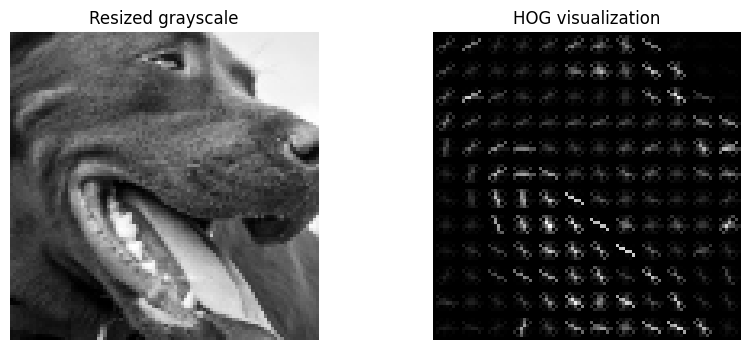

HOG feature length: 4356


In [9]:
show_hog_visualization(train_paths[0])

In [10]:
def build_hog_dataset(
    image_paths,
    class_to_index=None,
    target_size=(96, 96),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):
    X = []
    y = []

    for p in image_paths:
        feats = extract_hog_features(
            p,
            target_size=target_size,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block
        )
        X.append(feats)

        if class_to_index is not None:
            label = p.parent.name
            y.append(class_to_index[label])

    X = np.array(X)
    y = np.array(y) if class_to_index is not None else None

    return X, y

In [11]:
X_hog_dev, y_dev = build_hog_dataset(train_paths, class_to_index=ctoi)

In [12]:
# RF as clean baseline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(rf, X_hog_dev, y_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
oof_preds = cross_val_predict(rf, X_hog_dev, y_dev, cv=cv, n_jobs=-1)

print(f"HOG + RF CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_dev, oof_preds, target_names=sorted(ctoi.keys())))


HOG + RF CV macro F1: 0.5248 +/- 0.0201
              precision    recall  f1-score   support

       Angry       0.55      0.56      0.55       120
       Happy       0.57      0.53      0.55       120
         Sad       0.46      0.48      0.47       120

    accuracy                           0.53       360
   macro avg       0.53      0.53      0.53       360
weighted avg       0.53      0.53      0.53       360



In [13]:
import numpy as np
from PIL import Image
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import local_binary_pattern

In [ ]:
# extracting second feature, Local binary patterns
def extract_lbp_features(
    image_path,
    target_size=(96, 96),
    radius=1,
    method="uniform"
):
    """
    Load an image, convert to grayscale, resize, compute LBP,
    and return a normalized histogram of LBP codes.
    """
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    gray = rgb2gray(img)

    gray_resized = resize(gray, target_size, anti_aliasing=True)

    P = 8 * radius

    lbp = local_binary_pattern(gray_resized, P=P, R=radius, method=method)

    if method == "uniform":
        n_bins = P + 2
    else:
        n_bins = int(lbp.max() + 1)

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )

    return hist

In [15]:
lbp_feats = extract_lbp_features(train_paths[0])
print(lbp_feats.shape)
print(lbp_feats)

(10,)
[0.08550347 0.07953559 0.07074653 0.11924913 0.17664931 0.10828993
 0.06282552 0.07714844 0.08159722 0.13845486]


/Users/ishittaiyer/Desktop/sta314-project/.venv/lib/python3.12/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


In [16]:
def build_lbp_dataset(
    image_paths,
    class_to_index=None,
    target_size=(96, 96),
    radius=1,
    method="uniform"
):
    X = []
    y = []

    for p in image_paths:
        feats = extract_lbp_features(
            p,
            target_size=target_size,
            radius=radius,
            method=method
        )
        X.append(feats)

        if class_to_index is not None:
            y.append(class_to_index[p.parent.name])

    X = np.array(X)
    y = np.array(y) if class_to_index is not None else None

    return X, y

In [ ]:
X_lbp_dev, y_dev = build_lbp_dataset(train_paths, class_to_index=ctoi)
print(X_lbp_dev.shape, y_dev.shape)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(rf, X_lbp_dev, y_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
oof_preds = cross_val_predict(rf, X_lbp_dev, y_dev, cv=cv, n_jobs=-1)

print(f"LBP + RF CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_dev, oof_preds, target_names=sorted(ctoi.keys())))


(360, 10) (360,)
LBP + RF CV macro F1: 0.4308 +/- 0.0482
              precision    recall  f1-score   support

       Angry       0.40      0.45      0.43       120
       Happy       0.44      0.46      0.45       120
         Sad       0.46      0.39      0.42       120

    accuracy                           0.43       360
   macro avg       0.44      0.43      0.43       360
weighted avg       0.44      0.43      0.43       360



In [ ]:
X_combined1_dev = np.hstack([X_hog_dev, X_lbp_dev])

print(X_combined1_dev.shape, y_dev.shape)


(360, 4366) (360,)


In [19]:
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(rf, X_combined1_dev, y_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
oof_preds = cross_val_predict(rf, X_combined1_dev, y_dev, cv=cv, n_jobs=-1)

print(f"HOG + LBP + RF CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_dev, oof_preds, target_names=sorted(ctoi.keys())))


HOG + LBP + RF CV macro F1: 0.5224 +/- 0.0365
              precision    recall  f1-score   support

       Angry       0.57      0.56      0.56       120
       Happy       0.55      0.54      0.54       120
         Sad       0.46      0.47      0.46       120

    accuracy                           0.52       360
   macro avg       0.52      0.52      0.52       360
weighted avg       0.52      0.52      0.52       360



In [ ]:
# feature 3 :regional lbp for regional features

def extract_regional_lbp_features(
    image_path,
    target_size=(96, 96),
    grid_size=(4, 4),
    radius=1,
    method="uniform"
):
    """
    Extract regional LBP features by:
    1. loading image
    2. converting to grayscale
    3. resizing
    4. splitting into a grid
    5. computing an LBP histogram in each cell
    6. concatenating all histograms
    """
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    gray = rgb2gray(img)

    gray_resized = resize(gray, target_size, anti_aliasing=True)

    gray_uint8 = np.clip(np.round(gray_resized * 255), 0, 255).astype(np.uint8)

    P = 8 * radius
    lbp = local_binary_pattern(gray_uint8, P=P, R=radius, method=method)

    if method == "uniform":
        n_bins = P + 2
    else:
        n_bins = int(lbp.max() + 1)

    n_rows, n_cols = grid_size
    h, w = lbp.shape
    cell_h = h // n_rows
    cell_w = w // n_cols

    features = []

    for i in range(n_rows):
        for j in range(n_cols):
            cell = lbp[
                i * cell_h:(i + 1) * cell_h,
                j * cell_w:(j + 1) * cell_w
            ]

            hist, _ = np.histogram(
                cell.ravel(),
                bins=n_bins,
                range=(0, n_bins),
                density=True
            )

            features.extend(hist)

    return np.array(features, dtype=np.float32)

In [21]:
def build_regional_lbp_dataset(
    image_paths,
    class_to_index=None,
    target_size=(96, 96),
    grid_size=(4, 4),
    radius=1,
    method="uniform"
):
    X = []
    y = []

    for p in image_paths:
        feats = extract_regional_lbp_features(
            p,
            target_size=target_size,
            grid_size=grid_size,
            radius=radius,
            method=method
        )
        X.append(feats)

        if class_to_index is not None:
            y.append(class_to_index[p.parent.name])

    X = np.array(X)
    y = np.array(y) if class_to_index is not None else None

    return X, y

In [22]:
X_rlbp_dev, y_dev = build_regional_lbp_dataset(train_paths, class_to_index=ctoi)

print(X_rlbp_dev.shape, y_dev.shape)


(360, 160) (360,)


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(rf, X_rlbp_dev, y_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
oof_preds = cross_val_predict(rf, X_rlbp_dev, y_dev, cv=cv, n_jobs=-1)

print(f"rLBP + RF CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_dev, oof_preds, target_names=sorted(ctoi.keys())))


rLBP + RF CV macro F1: 0.5686 +/- 0.0469
              precision    recall  f1-score   support

       Angry       0.57      0.57      0.57       120
       Happy       0.62      0.72      0.67       120
         Sad       0.52      0.42      0.47       120

    accuracy                           0.57       360
   macro avg       0.57      0.57      0.57       360
weighted avg       0.57      0.57      0.57       360



In [24]:
# HOG + rLBP + LBP fused features on train_paths only
X_combined2_dev = np.hstack([X_hog_dev, X_rlbp_dev, X_lbp_dev])

X_combined2_dev.shape


(360, 4526)

In [25]:
cv_scores = cross_val_score(rf, X_combined2_dev, y_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
oof_preds = cross_val_predict(rf, X_combined2_dev, y_dev, cv=cv, n_jobs=-1)

print(f"HOG + rLBP + LBP + RF CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_dev, oof_preds, target_names=sorted(ctoi.keys())))


HOG + rLBP + LBP + RF CV macro F1: 0.5299 +/- 0.0162
              precision    recall  f1-score   support

       Angry       0.55      0.56      0.55       120
       Happy       0.58      0.61      0.59       120
         Sad       0.46      0.43      0.45       120

    accuracy                           0.53       360
   macro avg       0.53      0.53      0.53       360
weighted avg       0.53      0.53      0.53       360



In [26]:
X_combined3_dev = np.hstack([X_hog_dev, X_rlbp_dev])

print(X_combined3_dev.shape, y_dev.shape)


(360, 4516) (360,)


In [27]:
# RF on HOG + rLBP, evaluated with CV on train_paths only
cv_scores = cross_val_score(rf, X_combined3_dev, y_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
oof_preds = cross_val_predict(rf, X_combined3_dev, y_dev, cv=cv, n_jobs=-1)

print(f"HOG + rLBP + RF CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_dev, oof_preds, target_names=sorted(ctoi.keys())))


HOG + rLBP + RF CV macro F1: 0.5319 +/- 0.0413
              precision    recall  f1-score   support

       Angry       0.53      0.57      0.55       120
       Happy       0.57      0.62      0.59       120
         Sad       0.50      0.42      0.46       120

    accuracy                           0.54       360
   macro avg       0.53      0.54      0.53       360
weighted avg       0.53      0.54      0.53       360



In [28]:
import numpy as np
from PIL import Image
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import canny
from skimage.filters import sobel

In [ ]:
# 4th feature, regional stats
def extract_regional_stats_features(
    image_path,
    target_size=(96, 96),
    grid_size=(4, 4)
):
    """
    Extract regional summary features from an image:
    - mean intensity
    - std intensity
    - mean gradient magnitude
    - std gradient magnitude
    - edge density

    Returns one concatenated feature vector.
    """
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    gray = rgb2gray(img)
    gray_resized = resize(gray, target_size, anti_aliasing=True)

    grad = sobel(gray_resized)

    edges = canny(gray_resized)

    n_rows, n_cols = grid_size
    h, w = gray_resized.shape
    cell_h = h // n_rows
    cell_w = w // n_cols

    features = []

    for i in range(n_rows):
        for j in range(n_cols):
            r0, r1 = i * cell_h, (i + 1) * cell_h
            c0, c1 = j * cell_w, (j + 1) * cell_w

            gray_cell = gray_resized[r0:r1, c0:c1]
            grad_cell = grad[r0:r1, c0:c1]
            edge_cell = edges[r0:r1, c0:c1]

            features.append(gray_cell.mean())
            features.append(gray_cell.std())

            features.append(grad_cell.mean())
            features.append(grad_cell.std())

            features.append(edge_cell.mean())

    return np.array(features, dtype=np.float32)

In [30]:
def build_regional_stats_dataset(
    image_paths,
    class_to_index=None,
    target_size=(96, 96),
    grid_size=(4, 4)
):
    X = []
    y = []

    for p in image_paths:
        feats = extract_regional_stats_features(
            p,
            target_size=target_size,
            grid_size=grid_size
        )
        X.append(feats)

        if class_to_index is not None:
            y.append(class_to_index[p.parent.name])

    X = np.array(X)
    y = np.array(y) if class_to_index is not None else None

    return X, y

In [31]:
X_stats_dev, y_dev = build_regional_stats_dataset(train_paths, class_to_index=ctoi)

print(X_stats_dev.shape, y_dev.shape)


(360, 80) (360,)


In [32]:
# HOG + rLBP + regional stats fused features on train_paths only
X_combined4_dev = np.hstack([X_combined3_dev, X_stats_dev])

print(X_combined4_dev.shape, y_dev.shape)


(360, 4596) (360,)


In [33]:
cv_scores = cross_val_score(rf, X_combined4_dev, y_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
oof_preds = cross_val_predict(rf, X_combined4_dev, y_dev, cv=cv, n_jobs=-1)

print(f"HOG + rLBP + stats + RF CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_dev, oof_preds, target_names=sorted(ctoi.keys())))


HOG + rLBP + stats + RF CV macro F1: 0.5579 +/- 0.0418
              precision    recall  f1-score   support

       Angry       0.56      0.57      0.57       120
       Happy       0.58      0.57      0.58       120
         Sad       0.53      0.53      0.53       120

    accuracy                           0.56       360
   macro avg       0.56      0.56      0.56       360
weighted avg       0.56      0.56      0.56       360



In [ ]:
# tuned rf

rf1 = RandomForestClassifier(
    n_estimators=500,
        max_features="sqrt",      
        min_samples_leaf=3,       
        max_depth=None,          
        class_weight="balanced",  
    )

In [35]:
cv_scores = cross_val_score(rf1, X_combined4_dev, y_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
oof_preds = cross_val_predict(rf1, X_combined4_dev, y_dev, cv=cv, n_jobs=-1)

print(f"Tuned RF on HOG + rLBP + stats CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_dev, oof_preds, target_names=sorted(ctoi.keys())))


Tuned RF on HOG + rLBP + stats CV macro F1: 0.5802 +/- 0.0333
              precision    recall  f1-score   support

       Angry       0.56      0.62      0.59       120
       Happy       0.63      0.62      0.63       120
         Sad       0.57      0.53      0.55       120

    accuracy                           0.59       360
   macro avg       0.59      0.59      0.59       360
weighted avg       0.59      0.59      0.59       360



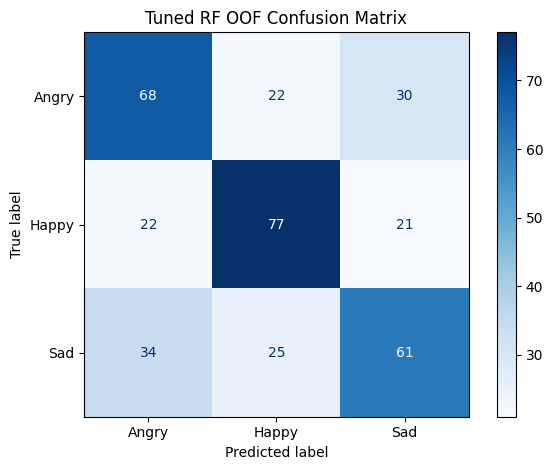

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

oof_preds = cross_val_predict(rf1, X_combined4_dev, y_dev, cv=cv, n_jobs=-1)

ConfusionMatrixDisplay.from_predictions(
    y_dev,
    oof_preds,
    display_labels=sorted(ctoi.keys()),
    cmap="Blues"
)
plt.title("Tuned RF OOF Confusion Matrix")
plt.tight_layout()
plt.show()


In [37]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [38]:
len(train_paths) # now switchign to k fold cv for ensemble, so using the entire training set here

360

In [39]:
X_hog_dev, y_dev = build_hog_dataset(train_paths, class_to_index=ctoi)
X_rlbp_dev, _ = build_regional_lbp_dataset(train_paths, class_to_index=ctoi)
X_stats_dev, _ = build_regional_stats_dataset(train_paths, class_to_index=ctoi)
X_dev = np.hstack([X_hog_dev, X_rlbp_dev, X_stats_dev])

In [40]:
# using extra trees and rf here for ensemble
rf3 = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=1,
)

et = ExtraTreesClassifier(
    n_estimators=500,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=1,
)



In [41]:
import pathlib

weights_path = RESNET_WEIGHTS
assert weights_path.exists(), weights_path



In [42]:
import pathlib
from tensorflow.keras.applications import ResNet50


resnet_feature_extractor = ResNet50(
    weights=str(weights_path),
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3),
)


In [43]:
import pathlib
import numpy as np
from PIL import Image

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

RESNET_IMAGE_SIZE = (224, 224)
RESNET_BATCH_SIZE = 32

assert RESNET_WEIGHTS.exists(), RESNET_WEIGHTS


resnet_feature_extractor = ResNet50(
    weights=str(RESNET_WEIGHTS) if isinstance(RESNET_WEIGHTS, pathlib.Path) else RESNET_WEIGHTS,
    include_top=False,
    pooling="avg",
    input_shape=RESNET_IMAGE_SIZE + (3,),
)

def load_resnet_image(image_path, target_size=RESNET_IMAGE_SIZE):
    img = Image.open(image_path).convert("RGB").resize(target_size)
    arr = np.array(img, dtype=np.float32)
    return preprocess_input(arr)

def build_resnet_dataset(
    image_paths,
    class_to_index=None,
    batch_size=RESNET_BATCH_SIZE,
    target_size=RESNET_IMAGE_SIZE,
):
    features = []
    labels = [] if class_to_index is not None else None

    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        batch_images = np.stack(
            [load_resnet_image(p, target_size=target_size) for p in batch_paths],
            axis=0,
        )
        batch_features = resnet_feature_extractor.predict(batch_images, verbose=0)
        features.append(batch_features)

        if class_to_index is not None:
            labels.extend(class_to_index[p.parent.name] for p in batch_paths)

    X = np.vstack(features).astype(np.float32)
    y = np.array(labels) if class_to_index is not None else None
    return X, y


In [44]:
X_resnet_dev, y_resnet_dev = build_resnet_dataset(train_paths, class_to_index=ctoi)

print("ResNet dev shape:", X_resnet_dev.shape)
print("Labels shape:", y_resnet_dev.shape)


ResNet dev shape: (360, 2048)
Labels shape: (360,)


In [45]:
rf_resnet = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

et_resnet = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

for name, model in [("ResNet + RF", rf_resnet), ("ResNet + ET", et_resnet)]:
    cv_scores = cross_val_score(model, X_resnet_dev, y_resnet_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
    oof_preds = cross_val_predict(model, X_resnet_dev, y_resnet_dev, cv=cv, n_jobs=-1)

    print(name)
    print(f"CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(classification_report(y_resnet_dev, oof_preds, target_names=sorted(ctoi.keys())))


ResNet + RF
CV macro F1: 0.7474 +/- 0.0565
              precision    recall  f1-score   support

       Angry       0.74      0.78      0.76       120
       Happy       0.76      0.82      0.79       120
         Sad       0.75      0.66      0.70       120

    accuracy                           0.75       360
   macro avg       0.75      0.75      0.75       360
weighted avg       0.75      0.75      0.75       360

ResNet + ET
CV macro F1: 0.7602 +/- 0.0341
              precision    recall  f1-score   support

       Angry       0.77      0.79      0.78       120
       Happy       0.74      0.86      0.80       120
         Sad       0.79      0.64      0.71       120

    accuracy                           0.76       360
   macro avg       0.77      0.76      0.76       360
weighted avg       0.77      0.76      0.76       360



In [46]:
# pretrained EfficientNetB0 embeddings + tree models
import numpy as np
from PIL import Image

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, cross_val_predict

EFFICIENTNET_IMAGE_SIZE = (224, 224)
EFFICIENTNET_BATCH_SIZE = 32

assert EFFICIENTNET_WEIGHTS.exists(), EFFICIENTNET_WEIGHTS

efficientnet_feature_extractor = EfficientNetB0(
    weights=str(EFFICIENTNET_WEIGHTS),
    include_top=False,
    pooling="avg",
    input_shape=EFFICIENTNET_IMAGE_SIZE + (3,),
)

def load_efficientnet_image(image_path, target_size=EFFICIENTNET_IMAGE_SIZE):
    img = Image.open(image_path).convert("RGB").resize(target_size)
    arr = np.array(img, dtype=np.float32)
    return preprocess_input(arr)

def build_efficientnet_dataset(
    image_paths,
    class_to_index=None,
    batch_size=EFFICIENTNET_BATCH_SIZE,
    target_size=EFFICIENTNET_IMAGE_SIZE,
):
    features = []
    labels = [] if class_to_index is not None else None

    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        batch_images = np.stack(
            [load_efficientnet_image(p, target_size=target_size) for p in batch_paths],
            axis=0,
        )
        batch_features = efficientnet_feature_extractor.predict(batch_images, verbose=0)
        features.append(batch_features)

        if class_to_index is not None:
            labels.extend(class_to_index[p.parent.name] for p in batch_paths)

    X = np.vstack(features).astype(np.float32)
    y = np.array(labels) if class_to_index is not None else None
    return X, y


In [47]:
X_effnet_dev, y_effnet_dev = build_efficientnet_dataset(train_paths, class_to_index=ctoi)

print("EfficientNet dev shape:", X_effnet_dev.shape)
print("Labels shape:", y_effnet_dev.shape)


EfficientNet dev shape: (360, 1280)
Labels shape: (360,)


In [48]:
rf_effnet = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

et_effnet = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

for name, model in [("EfficientNet + RF", rf_effnet), ("EfficientNet + ET", et_effnet)]:
    cv_scores = cross_val_score(model, X_effnet_dev, y_effnet_dev, cv=cv, scoring="f1_macro", n_jobs=-1)
    oof_preds = cross_val_predict(model, X_effnet_dev, y_effnet_dev, cv=cv, n_jobs=-1)

    print(name)
    print(f"CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(classification_report(y_effnet_dev, oof_preds, target_names=sorted(ctoi.keys())))


EfficientNet + RF
CV macro F1: 0.7459 +/- 0.0472
              precision    recall  f1-score   support

       Angry       0.81      0.80      0.80       120
       Happy       0.71      0.82      0.76       120
         Sad       0.75      0.63      0.68       120

    accuracy                           0.75       360
   macro avg       0.75      0.75      0.75       360
weighted avg       0.75      0.75      0.75       360

EfficientNet + ET
CV macro F1: 0.7803 +/- 0.0321
              precision    recall  f1-score   support

       Angry       0.84      0.82      0.83       120
       Happy       0.74      0.86      0.80       120
         Sad       0.78      0.68      0.72       120

    accuracy                           0.78       360
   macro avg       0.79      0.78      0.78       360
weighted avg       0.79      0.78      0.78       360



In [49]:
for name, model in [("EfficientNet + RF", rf_effnet), ("EfficientNet + ET", et_effnet)]:
    scores = cross_val_score(
        model,
        X_effnet_dev,
        y_effnet_dev,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")


EfficientNet + RF: mean=0.7459, std=0.0472
EfficientNet + ET: mean=0.7803, std=0.0321


In [50]:
for name, model in [("ResNet + RF", rf_resnet), ("ResNet + ET", et_resnet)]:
    scores = cross_val_score(
        model,
        X_resnet_dev,
        y_resnet_dev,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")


ResNet + RF: mean=0.7474, std=0.0565
ResNet + ET: mean=0.7602, std=0.0341


In [ ]:
X_rlbp_dev, _ = build_regional_lbp_dataset(train_paths, class_to_index=ctoi)
X_hog_dev, _ = build_hog_dataset(train_paths, class_to_index=ctoi)
X_stats_dev, _ = build_regional_stats_dataset(train_paths, class_to_index=ctoi)

X_effnet_rlbp_dev = np.hstack([X_effnet_dev, X_rlbp_dev])
X_effnet_all_dev = np.hstack([X_effnet_dev, X_hog_dev, X_rlbp_dev, X_stats_dev])

print("EffNet only:", X_effnet_dev.shape)
print("EffNet + rLBP:", X_effnet_rlbp_dev.shape)
print("EffNet + all handcrafted:", X_effnet_all_dev.shape)
print("Labels:", y_effnet_dev.shape)


EffNet only: (360, 1280)
EffNet + rLBP: (360, 1440)
EffNet + all handcrafted: (360, 5876)
Labels: (360,)


In [52]:
assert X_effnet_dev.shape[0] == X_rlbp_dev.shape[0] == X_hog_dev.shape[0] == X_stats_dev.shape[0], \
    "Feature row counts don't match — path lists are misaligned"

In [53]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report

et_effnet_only = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

et_effnet_rlbp = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

et_effnet_all = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

runs = [
    ("EfficientNet + ET", et_effnet_only, X_effnet_dev, y_effnet_dev),
    ("EfficientNet + rLBP + ET", et_effnet_rlbp, X_effnet_rlbp_dev, y_effnet_dev),
    ("EfficientNet + all handcrafted + ET", et_effnet_all, X_effnet_all_dev, y_effnet_dev),
]

for name, model, X, y in runs:
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    oof_preds = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)

    print(name)
    print(f"CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(classification_report(y, oof_preds, target_names=sorted(ctoi.keys())))


EfficientNet + ET
CV macro F1: 0.7803 +/- 0.0321
              precision    recall  f1-score   support

       Angry       0.84      0.82      0.83       120
       Happy       0.74      0.86      0.80       120
         Sad       0.78      0.68      0.72       120

    accuracy                           0.78       360
   macro avg       0.79      0.78      0.78       360
weighted avg       0.79      0.78      0.78       360

EfficientNet + rLBP + ET
CV macro F1: 0.8007 +/- 0.0485
              precision    recall  f1-score   support

       Angry       0.83      0.82      0.83       120
       Happy       0.76      0.88      0.82       120
         Sad       0.83      0.70      0.76       120

    accuracy                           0.80       360
   macro avg       0.81      0.80      0.80       360
weighted avg       0.81      0.80      0.80       360

EfficientNet + all handcrafted + ET
CV macro F1: 0.7016 +/- 0.0226
              precision    recall  f1-score   support

       Angr

In [54]:
# 5-fold CV comparison on the full training split
cv_runs = [
    ("EfficientNet + ET", et_effnet_only, X_effnet_dev, y_effnet_dev),
    ("EfficientNet + rLBP + ET", et_effnet_rlbp, X_effnet_rlbp_dev, y_effnet_dev),
    ("EfficientNet + all handcrafted + ET", et_effnet_all, X_effnet_all_dev, y_effnet_dev),
]

for name, model, X, y in cv_runs:
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")


EfficientNet + ET: mean=0.7803, std=0.0321
EfficientNet + rLBP + ET: mean=0.8007, std=0.0485
EfficientNet + all handcrafted + ET: mean=0.7016, std=0.0226


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

print("Fused train shape:", X_effnet_rlbp_dev.shape)

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

et_base = ExtraTreesClassifier(
    random_state=42,
    n_jobs=1,
)

param_dist_no_bootstrap = {
    "n_estimators": [300, 500, 800, 1200],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_features": ["sqrt", "log2", 0.2, 0.35, 0.5, 0.75],
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 3, 5, 8, 10],
    "max_leaf_nodes": [None, 50, 100, 200, 400],
    "min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2],
    "bootstrap": [False],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "ccp_alpha": [0.0, 1e-5, 1e-4, 1e-3, 1e-2],
}

param_dist_bootstrap = {
    "n_estimators": [300, 500, 800, 1200],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_features": ["sqrt", "log2", 0.2, 0.35, 0.5, 0.75],
    "max_depth": [None, 10, 20, 30, 40, 60],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 3, 5, 8, 10],
    "max_leaf_nodes": [None, 50, 100, 200, 400],
    "min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2],
    "bootstrap": [True],
    "max_samples": [0.5, 0.7, 0.85, 1.0],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "ccp_alpha": [0.0, 1e-5, 1e-4, 1e-3, 1e-2],
}

search_configs = [
    ("no_bootstrap", param_dist_no_bootstrap, 40),
    ("bootstrap", param_dist_bootstrap, 40),
]

best_search = None
best_name = None
best_score = -np.inf

for name, param_dist, n_iter in search_configs:
    search = RandomizedSearchCV(
        estimator=et_base,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="f1_macro",
        cv=cv_tune,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        refit=True,
    )
    search.fit(X_effnet_rlbp_dev, y_effnet_dev)

    print(f"\n{name} best CV macro F1: {search.best_score_:.4f}")
    print(search.best_params_)

    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_search = search
        best_name = name

print(f"\nOverall best search: {best_name}")
print(f"Best tuning CV macro F1: {best_score:.4f}")
print("Best params:")
print(best_search.best_params_)

best_et_effnet_rlbp = best_search.best_estimator_


Fused train shape: (360, 1440)
Fitting 5 folds for each of 40 candidates, totalling 200 fits

no_bootstrap best CV macro F1: 0.8272
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'max_leaf_nodes': None, 'max_features': 0.5, 'max_depth': None, 'criterion': 'gini', 'class_weight': None, 'ccp_alpha': 1e-05, 'bootstrap': False}
Fitting 5 folds for each of 40 candidates, totalling 200 fits

bootstrap best CV macro F1: 0.7660
{'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 3, 'min_impurity_decrease': 0.0, 'max_samples': 1.0, 'max_leaf_nodes': None, 'max_features': 0.2, 'max_depth': 30, 'criterion': 'gini', 'class_weight': None, 'ccp_alpha': 0.001, 'bootstrap': True}

Overall best search: no_bootstrap
Best tuning CV macro F1: 0.8272
Best params:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'max_leaf_nodes': None, 'max_features': 0.5, 'max_depth': None, 'criterion': 'gini

In [56]:
oof_preds = cross_val_predict(
    best_et_effnet_rlbp,
    X_effnet_rlbp_dev,
    y_effnet_dev,
    cv=cv,
    n_jobs=-1,
)

cv_scores = cross_val_score(
    best_et_effnet_rlbp,
    X_effnet_rlbp_dev,
    y_effnet_dev,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)

print(f"Tuned EfficientNet + rLBP + ET CV macro F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(classification_report(y_effnet_dev, oof_preds, target_names=sorted(ctoi.keys())))


Tuned EfficientNet + rLBP + ET CV macro F1: 0.8272 +/- 0.0374
              precision    recall  f1-score   support

       Angry       0.88      0.83      0.86       120
       Happy       0.77      0.91      0.84       120
         Sad       0.84      0.74      0.79       120

    accuracy                           0.83       360
   macro avg       0.83      0.83      0.83       360
weighted avg       0.83      0.83      0.83       360



In [57]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

et_focused_base = ExtraTreesClassifier(
    random_state=42,
    n_jobs=1,
)

param_dist_focused = {
    "n_estimators": [400, 500, 600, 700, 800],
    "max_features": [0.4, 0.45, 0.5, 0.55, 0.6],
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [2, 3, 4, 5],
    "max_depth": [None, 30, 40, 60],
    "min_impurity_decrease": [0.0, 1e-5, 1e-4],
    "ccp_alpha": [0.0, 5e-6, 1e-5, 5e-5, 1e-4],
    "bootstrap": [False],
    "class_weight": [None, "balanced"],
    "criterion": ["gini"],
}

focused_search = RandomizedSearchCV(
    estimator=et_focused_base,
    param_distributions=param_dist_focused,
    n_iter=60,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True,
)

focused_search.fit(X_effnet_rlbp_dev, y_effnet_dev)

print(f"Focused best tuning CV macro F1: {focused_search.best_score_:.4f}")
print("Focused best params:")
print(focused_search.best_params_)

best_et_effnet_rlbp_focused = focused_search.best_estimator_


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Focused best tuning CV macro F1: 0.8275
Focused best params:
{'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'max_features': 0.5, 'max_depth': None, 'criterion': 'gini', 'class_weight': None, 'ccp_alpha': 5e-05, 'bootstrap': False}


In [58]:
results = (
    pd.DataFrame(focused_search.cv_results_)
    .sort_values("mean_test_score", ascending=False)
    [[
        "mean_test_score",
        "std_test_score",
        "param_n_estimators",
        "param_max_features",
        "param_min_samples_leaf",
        "param_min_samples_split",
        "param_max_depth",
        "param_min_impurity_decrease",
        "param_ccp_alpha",
        "param_class_weight",
    ]]
)

results.head(10)


,mean_test_score,std_test_score,param_n_estimators,param_max_features,param_min_samples_leaf,param_min_samples_split,param_max_depth,param_min_impurity_decrease,param_ccp_alpha,param_class_weight
5,0.827450,0.040702,600,0.50,1,2,None,0.00000,0.000050,NaN
24,0.827070,0.040615,600,0.50,1,3,30,0.00000,0.000000,NaN
57,0.824677,0.041390,800,0.60,1,4,None,0.00000,0.000005,balanced
20,0.823849,0.041387,800,0.45,1,3,None,0.00000,0.000000,NaN
48,0.821698,0.042236,700,0.60,1,4,None,0.00010,0.000005,balanced
13,0.821698,0.042236,700,0.60,1,4,60,0.00001,0.000050,balanced
36,0.821662,0.046618,600,0.50,1,5,40,0.00010,0.000050,NaN
32,0.821112,0.043022,600,0.60,1,3,60,0.00000,0.000005,NaN
0,0.821041,0.049553,400,0.50,1,5,30,0.00010,0.000010,NaN
6,0.818564,0.040954,700,0.60,1,2,30,0.00000,0.000010,NaN


In [59]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

et_stack = best_et_effnet_rlbp_focused

rf_stack = RandomForestClassifier(
    n_estimators=600,
    max_features="sqrt",
    min_samples_leaf=2,
    bootstrap=True,
    class_weight="balanced",
    random_state=43,
    n_jobs=1,
)

svm_stack = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95),
    SVC(C=6.3, kernel="rbf", probability=True, class_weight="balanced", random_state=42),
)

stack_clf = StackingClassifier(
    estimators=[
        ("et", et_stack),
        ("rf", rf_stack),
        ("svm", svm_stack),
    ],
    final_estimator=LogisticRegression(
        C=1.0,
        max_iter=5000,
        random_state=42,
    ),
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
    n_jobs=1,
)

scores = cross_val_score(
    stack_clf,
    X_effnet_rlbp_dev,
    y_effnet_dev,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)

print(f"Stacking CV macro F1: {scores.mean():.4f} +/- {scores.std():.4f}")


Stacking CV macro F1: 0.8426 +/- 0.0361


In [60]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

svm_base = make_pipeline(
    StandardScaler(),
    PCA(),
    SVC(kernel="rbf", probability=True, random_state=42),
)

svm_param_dist = {
    "pca__n_components": [0.90, 0.95, 0.98, 120, 180, 240],
    "svc__C": np.logspace(-1, 2, 8),
    "svc__gamma": ["scale", 1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "svc__class_weight": [None, "balanced"],
}

svm_search = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=svm_param_dist,
    n_iter=25,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True,
)

svm_search.fit(X_effnet_rlbp_dev, y_effnet_dev)

print(f"SVM best tuning CV macro F1: {svm_search.best_score_:.4f}")
print(svm_search.best_params_)

best_svm_effnet_rlbp = svm_search.best_estimator_


Fitting 5 folds for each of 25 candidates, totalling 125 fits
SVM best tuning CV macro F1: 0.8479
{'svc__gamma': 0.001, 'svc__class_weight': None, 'svc__C': 13.894954943731374, 'pca__n_components': 180}


In [61]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_candidates = []

for C in [0.1, 0.3, 1.0, 3.0, 10.0]:
    for class_weight in [None, "balanced"]:
        for passthrough in [False, True]:
            model = StackingClassifier(
                estimators=[
                    ("et", best_et_effnet_rlbp_focused),
                    ("svm", best_svm_effnet_rlbp),
                ],
                final_estimator=LogisticRegression(
                    C=C,
                    class_weight=class_weight,
                    max_iter=5000,
                    random_state=42,
                ),
                stack_method="predict_proba",
                passthrough=passthrough,
                cv=5,
                n_jobs=1,
            )

            scores = cross_val_score(
                model,
                X_effnet_rlbp_dev,
                y_effnet_dev,
                cv=cv,
                scoring="f1_macro",
                n_jobs=-1,
            )

            mean_score = scores.mean()
            std_score = scores.std()

            stack_candidates.append(
                (mean_score, std_score, C, class_weight, passthrough, model)
            )

            print(
                f"C={C}, class_weight={class_weight}, passthrough={passthrough}: "
                f"mean={mean_score:.4f}, std={std_score:.4f}"
            )

best_stack = max(stack_candidates, key=lambda x: x[0])
best_stack_model = best_stack[-1]

print("\nBest stack:")
print(
    f"mean={best_stack[0]:.4f}, std={best_stack[1]:.4f}, "
    f"C={best_stack[2]}, class_weight={best_stack[3]}, passthrough={best_stack[4]}"
)



C=0.1, class_weight=None, passthrough=False: mean=0.8427, std=0.0417
C=0.1, class_weight=None, passthrough=True: mean=0.8305, std=0.0241
C=0.1, class_weight=balanced, passthrough=False: mean=0.8400, std=0.0369


KeyboardInterrupt: 

In [62]:
best_stack_model = StackingClassifier(
    estimators=[
        ("et", best_et_effnet_rlbp_focused),
        ("svm", best_svm_effnet_rlbp),
    ],
    final_estimator=LogisticRegression(
        C=0.1,
        class_weight=None,
        max_iter=5000,
        random_state=42,
    ),
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
    n_jobs=1,
)


In [63]:
finalists = [
    ("Tuned ET", best_et_effnet_rlbp_focused),
    ("ET + SVM stack", best_stack_model),
]

for name, model in finalists:
    scores = cross_val_score(
        model,
        X_effnet_rlbp_dev,
        y_effnet_dev,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")


Tuned ET: mean=0.8275, std=0.0407
ET + SVM stack: mean=0.8427, std=0.0417


              precision    recall  f1-score   support

       Angry       0.88      0.85      0.86       120
       Happy       0.80      0.88      0.84       120
         Sad       0.86      0.79      0.82       120

    accuracy                           0.84       360
   macro avg       0.84      0.84      0.84       360
weighted avg       0.84      0.84      0.84       360



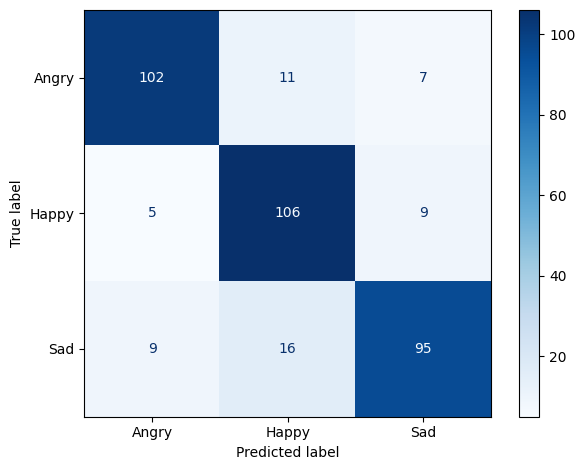

In [ ]:
winner = best_stack_model  

oof_preds = cross_val_predict(
    winner,
    X_effnet_rlbp_dev,
    y_effnet_dev,
    cv=cv,
    n_jobs=-1,
)

print(classification_report(y_effnet_dev, oof_preds, target_names=sorted(ctoi.keys())))
ConfusionMatrixDisplay.from_predictions(
    y_effnet_dev,
    oof_preds,
    display_labels=sorted(ctoi.keys()),
    cmap="Blues"
)
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

       Angry       0.88      0.86      0.87       120
       Happy       0.81      0.88      0.84       120
         Sad       0.85      0.79      0.82       120

    accuracy                           0.84       360
   macro avg       0.85      0.84      0.84       360
weighted avg       0.85      0.84      0.84       360



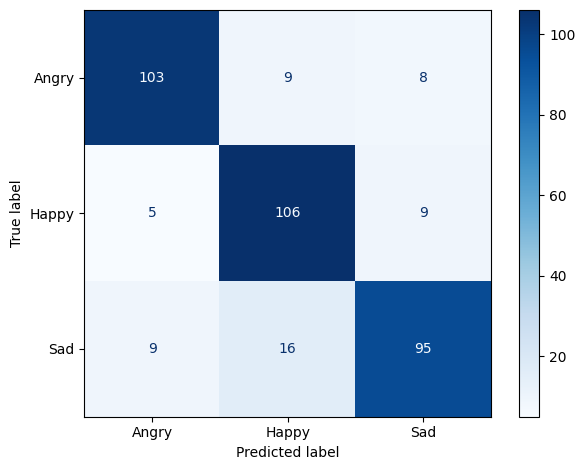

In [65]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

oof_preds = cross_val_predict(
    best_stack_model,
    X_effnet_rlbp_dev,
    y_effnet_dev,
    cv=cv,
    n_jobs=-1,
)

print(classification_report(y_effnet_dev, oof_preds, target_names=sorted(ctoi.keys())))

ConfusionMatrixDisplay.from_predictions(
    y_effnet_dev,
    oof_preds,
    display_labels=sorted(ctoi.keys()),
    cmap="Blues"
)
plt.tight_layout()
plt.show()


Train shape: (360, 1440) (360,)
Test shape: (90, 1440) (90,)
              precision    recall  f1-score   support

       Angry       0.97      0.97      0.97        30
       Happy       0.87      0.90      0.89        30
         Sad       0.90      0.87      0.88        30

    accuracy                           0.91        90
   macro avg       0.91      0.91      0.91        90
weighted avg       0.91      0.91      0.91        90



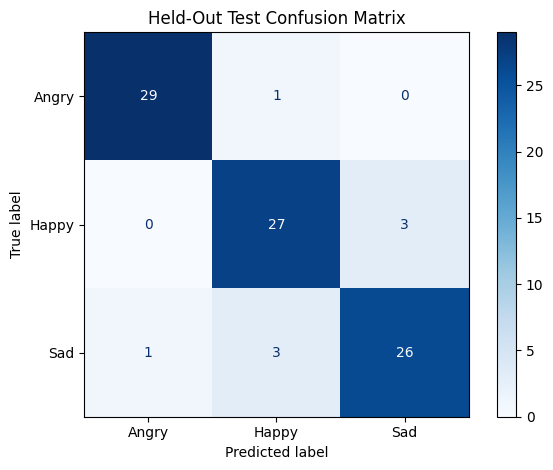

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

X_test_effnet, y_test = build_efficientnet_dataset(test_paths, class_to_index=ctoi)
X_test_rlbp, _ = build_regional_lbp_dataset(test_paths, class_to_index=ctoi)
X_test_effnet_rlbp = np.hstack([X_test_effnet, X_test_rlbp])

print("Train shape:", X_effnet_rlbp_dev.shape, y_effnet_dev.shape)
print("Test shape:", X_test_effnet_rlbp.shape, y_test.shape)

best_stack_model.fit(X_effnet_rlbp_dev, y_effnet_dev)
test_preds = best_stack_model.predict(X_test_effnet_rlbp)

print(classification_report(y_test, test_preds, target_names=sorted(ctoi.keys())))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds,
    display_labels=sorted(ctoi.keys()),
    cmap="Blues"
)
plt.title("Held-Out Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
import csv
import numpy as np
from pathlib import Path

X_full_effnet, y_full = build_efficientnet_dataset(train1_paths, class_to_index=ctoi)
X_full_rlbp, _ = build_regional_lbp_dataset(train1_paths, class_to_index=ctoi)
X_full_effnet_rlbp = np.hstack([X_full_effnet, X_full_rlbp])

X_submit_effnet, _ = build_efficientnet_dataset(test1_paths, class_to_index=None)
X_submit_rlbp, _ = build_regional_lbp_dataset(test1_paths, class_to_index=None)
X_submit_effnet_rlbp = np.hstack([X_submit_effnet, X_submit_rlbp])

print("Full train shape:", X_full_effnet_rlbp.shape, y_full.shape)
print("Submission test shape:", X_submit_effnet_rlbp.shape)

best_stack_model.fit(X_full_effnet_rlbp, y_full)

submit_preds_idx = best_stack_model.predict(X_submit_effnet_rlbp)
submit_preds = [itoc[i] for i in submit_preds_idx]

submission_path = Path("submission_stack_et_svm.csv")

with submission_path.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "label"])
    for path, label in zip(test1_paths, submit_preds):
        writer.writerow([path.name, label])

print(f"Saved submission to: {submission_path}")
print("First 5 predictions:")
for path, label in list(zip(test1_paths, submit_preds))[:5]:
    print(path.name, label)


Full train shape: (450, 1440) (450,)
Submission test shape: (300, 1440)
Saved submission to: submission_stack_et_svm.csv
First 5 predictions:
img_000003.jpg Angry
img_000007.jpg Angry
img_000009.jpg Angry
img_000011.jpg Angry
img_000013.jpg Angry


In [68]:
import csv

with submission_path.open() as f:
    rows = list(csv.reader(f))

print("Total rows including header:", len(rows))
print("Header:", rows[0])
print("First 3 prediction rows:", rows[1:4])

Total rows including header: 301
Header: ['id', 'label']
First 3 prediction rows: [['img_000003.jpg', 'Angry'], ['img_000007.jpg', 'Angry'], ['img_000009.jpg', 'Angry']]


In [70]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
import numpy as np
import pandas as pd

cv_repeat = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

scores = cross_validate(
    best_stack_model,
    X_full_effnet_rlbp,
    y_full,
    cv=cv_repeat,
    scoring="f1_macro",
    return_train_score=True,
    n_jobs=-1,
)

print(f"Train macro F1: {scores['train_score'].mean():.4f} +/- {scores['train_score'].std():.4f}")
print(f"Valid macro F1: {scores['test_score'].mean():.4f} +/- {scores['test_score'].std():.4f}")
print(f"Gap: {(scores['train_score'].mean() - scores['test_score'].mean()):.4f}")


Train macro F1: 1.0000 +/- 0.0000
Valid macro F1: 0.8813 +/- 0.0313
Gap: 0.1187


In [71]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

cv_repeat = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

for name, model in [
    ("Tuned ET", best_et_effnet_rlbp_focused),
    ("ET + SVM stack", best_stack_model),
]:
    scores = cross_validate(
        model,
        X_full_effnet_rlbp,
        y_full,
        cv=cv_repeat,
        scoring="f1_macro",
        return_train_score=True,
        n_jobs=-1,
    )
    train_mean = scores["train_score"].mean()
    valid_mean = scores["test_score"].mean()
    gap = train_mean - valid_mean

    print(name)
    print(f"Train macro F1: {train_mean:.4f}")
    print(f"Valid macro F1: {valid_mean:.4f}")
    print(f"Gap: {gap:.4f}\n")


Tuned ET
Train macro F1: 1.0000
Valid macro F1: 0.8531
Gap: 0.1469

ET + SVM stack
Train macro F1: 1.0000
Valid macro F1: 0.8809
Gap: 0.1191



In [72]:
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(42)
y_shuffled = rng.permutation(y_full)

shuffle_scores = cross_val_score(
    best_stack_model,
    X_full_effnet_rlbp,
    y_shuffled,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
)

print(f"Shuffled-label macro F1: {shuffle_scores.mean():.4f} +/- {shuffle_scores.std():.4f}")


Shuffled-label macro F1: 0.2748 +/- 0.0335
